# Set-up

In [1]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [3]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [4]:
path_out = "scratch/2025_06_22"

# Load genome

In [5]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [6]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [7]:
path_peaks = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/peaks/D15_merged_ENP_peaks.bed"
path_schema = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/3-cyt_rna_celltype/snapatac2/SC.beta.narrowPeak.schema"
schema = pd.read_csv(path_schema, header=None, sep='\t')[0].tolist()  # convert schema to a list
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=schema)  # corrected to use schema

In [8]:
# Remove duplicate chrom start and end taking the highest q_value
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
7,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193
109643,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150
6,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142
3021,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661
112224,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146
...,...,...,...,...,...,...,...,...,...,...
125611,chr18,78739087,78739330,.,13,.,1.479915,2.706340,1.309857,94
108848,chr17,17019608,17019854,.,13,.,1.675393,2.705390,1.308933,129
119139,chr18,7063745,7064068,.,13,.,1.617133,2.703760,1.307358,73
267882,chr8,144538109,144538392,.,13,.,1.732673,2.701570,1.305214,185


# Load motifs

In [9]:
motifs = read_meme("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")
motif_names = np.array(list(motifs.keys()))

In [10]:
tmp = pd.read_csv("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/tfs_initial.txt", header=None, sep='\t', names=["motif_id", "annotated_tf", "evalue"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]
motif_id_mp

motif_id
Average_34                       ZN143_MOUSE.H11MO.0.A
Average_15                               CTCF_MA0139.1
Average_23                        NFYB_HUMAN.H11MO.0.A
Average_30                              HNF4G_MA0484.1
Average_18                        NRF1_HUMAN.H11MO.0.A
Average_39                        MAFB_HUMAN.H11MO.0.B
Average_38                        NDF2_MOUSE.H11MO.0.A
Average_27                         SP2_HUMAN.H11MO.0.A
D15_ENP.counts.pattern_32.pfm               ETV6_ETS_1
Average_14                              HNF1B_MA0153.2
Average_16                        TYY1_HUMAN.H11MO.0.A
Average_32                       FOXA2_HUMAN.H11MO.0.A
Average_40                        ELK1_HUMAN.H11MO.0.B
Average_6                         TAL1_HUMAN.H11MO.0.A
Average_42                        RFX6_MOUSE.H11MO.0.C
Average_35                           JUN+JUNB_MA1133.1
Average_25                                ARNTL_bHLH_1
Average_22                             ZBTB33_MA0527.1
A

# Load model

In [11]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [12]:
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [13]:
from tangermeme.io import extract_loci

# find the peaks that intersect with the isl1 enhancer coordinates
def intersects_with_peak(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return True
    return False

# and add the peak coordinates to the dataframe
def get_peak_coordinates(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return f"{chrom}:{peak_start}-{peak_end}"
    return None

In [14]:
# Read in the headers from each sequence to get the coordinates
path_fasta = "scratch/2025_06_22/isl_CRE.fa"
seqs = pyfaidx.Fasta(path_fasta)
seq_headers = list(seqs.keys())
isl1_enhancer_df = pd.DataFrame(seq_headers, columns=['header'])
isl1_enhancer_df['chrom'] = isl1_enhancer_df['header'].str.split(':').str[0]
isl1_enhancer_df['start'] = isl1_enhancer_df['header'].str.split(':').str[1].str.split('-').str[0].astype(int)
isl1_enhancer_df['end'] = isl1_enhancer_df['header'].str.split(':').str[1].str.split('-').str[1].astype(int)
isl1_enhancer_df['intersects_peak'] = isl1_enhancer_df.apply(intersects_with_peak, peaks=peaks, axis=1)
isl1_enhancer_df['peak_coordinates'] = isl1_enhancer_df.apply(get_peak_coordinates, peaks=peaks, axis=1)
isl1_enhancer_df["peak_chrom"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[0]
isl1_enhancer_df["peak_start"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[0].astype(int)
isl1_enhancer_df["peak_end"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[1].astype(int)
isl1_enhancer_df

,header,chrom,start,end,intersects_peak,peak_coordinates,peak_chrom,peak_start,peak_end
0,chr5:51225727-51226784,chr5,51225727,51226784,True,chr5:51226455-51226670,chr5,51226455,51226670
1,chr5:51392146-51392917,chr5,51392146,51392917,True,chr5:51392398-51392614,chr5,51392398,51392614
2,chr5:51398691-51400017,chr5,51398691,51400017,True,chr5:51398819-51399745,chr5,51398819,51399745


# Get baseline level of predictions

In [15]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=["/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw"],
    chroms=["chr5"]
)

In [16]:
y_0 = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

  0%|          | 0/414 [00:00<?, ?it/s]

100%|██████████| 414/414 [00:15<00:00, 27.50it/s]


In [17]:
peaks_selected = peaks[peaks["chrom"] == "chr5"]

# Add the predicted counts to the peaks dataframe
peaks_selected["log_counts"] = torch.log(torch.sum(signals, dim=(1,2))).cpu().numpy()
peaks_selected["log_counts_pred"] = y_0[:, 0].cpu().numpy()

# Annote peaks as Enhancer_1, Enhancer_2, etc.
peaks_selected = peaks_selected.merge(isl1_enhancer_df[["peak_chrom", "peak_start", "peak_end"]], 
                                       left_on=["chrom", "start", "end"], 
                                       right_on=["peak_chrom", "peak_start", "peak_end"], 
                                       how="left", suffixes=("", "_enhancer"))
peaks_selected['enhancer_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer',
    np.nan
)
peaks_selected['enhancer_annotation'] = peaks_selected.groupby('chrom').cumcount() + 1
peaks_selected['enhancer_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer_' + peaks_selected['enhancer_annotation'].astype(str),
    np.nan
)

# Drop the temporary columns used for annotation
peaks_selected = peaks_selected.drop(columns=["peak_chrom", "peak_start", "peak_end"])
peaks_selected["enhancer_annotation"].value_counts()

/tmp/ipykernel_2128644/4148722850.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peaks_selected["log_counts"] = torch.log(torch.sum(signals, dim=(1,2))).cpu().numpy()
/tmp/ipykernel_2128644/4148722850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peaks_selected["log_counts_pred"] = y_0[:, 0].cpu().numpy()


Enhancer_2023     1
Enhancer_6290     1
Enhancer_11695    1
Name: enhancer_annotation, dtype: int64

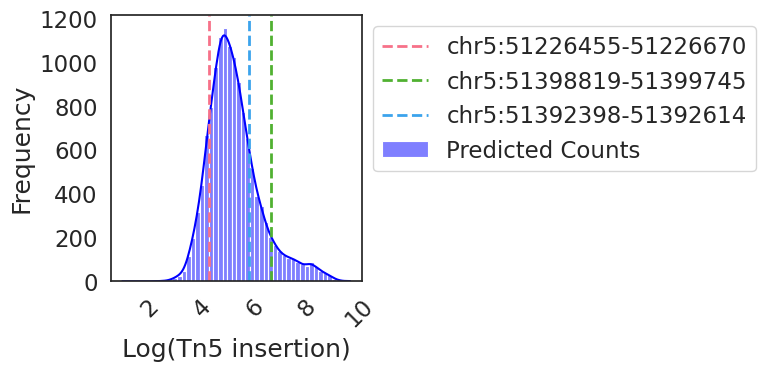

In [18]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each ISL1 enhancer as a vertical line each with a different color
    enhancer_colors = sns.color_palette("husl", peaks_selected["enhancer_annotation"].nunique())
    for i, (enhancer_name, group) in enumerate(peaks_selected.groupby("enhancer_annotation")):
        if enhancer_name.startswith("Enhancer_"):
            enhancer_color = enhancer_colors[i % len(enhancer_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=enhancer_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# Enhancer ISM

In [19]:
sys.path.append(path_out)
from utils import greedy_ism

In [20]:
dtype = torch.float64

In [21]:
# Define model and ism params
seq_len = 2114
target_len = 1000
ism_window = 500
plot_window = 200

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - ism_window // 2
seq_end = seq_center + ism_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - ism_window // 2
target_end = target_center + ism_window // 2

# Plot starts
plot_seq_center = 1050
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 807, seq_end: 1307
target_start: 250, target_end: 750
plot_seq_start: 957, plot_seq_end: 1157
plot_target_start: 400, plot_target_end: 600


In [22]:
peaks_selected[peaks_selected["enhancer_annotation"].notnull()]

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,enhancer_annotation
2022,chr5,51398819,51399745,.,1000,.,13.046875,245.616241,243.168518,633,6.658011,6.633110,Enhancer_2023
6289,chr5,51392398,51392614,.,320,.,3.461344,33.981609,32.077003,104,5.393628,5.798398,Enhancer_6290
11694,chr5,51226455,51226670,.,65,.,2.787790,8.181960,6.571065,130,4.158883,4.258169,Enhancer_11695


In [23]:
X_optimized = []

## Enhancer #1

In [24]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[0]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[0]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51398819-51399745: 6.6331095695495605


In [25]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51398719-51399845


In [26]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [27]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [28]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00,  9.69it/s]


tensor([[6.6329]])

In [29]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 6.633
Iteration 1/10 - y_hat: 7.281
Iteration 2/10 - y_hat: 7.748
Iteration 3/10 - y_hat: 8.074
Iteration 4/10 - y_hat: 8.446
Iteration 5/10 - y_hat: 8.766
Iteration 6/10 - y_hat: 9.040
Iteration 7/10 - y_hat: 9.285
Iteration 8/10 - y_hat: 9.506
Iteration 9/10 - y_hat: 9.753
Iteration 10/10 - y_hat: 10.292


In [30]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:29<00:00,  1.47s/it]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

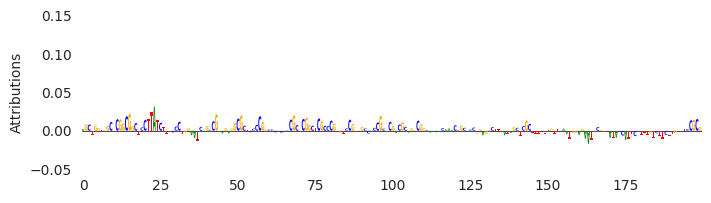

In [31]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [32]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.37it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

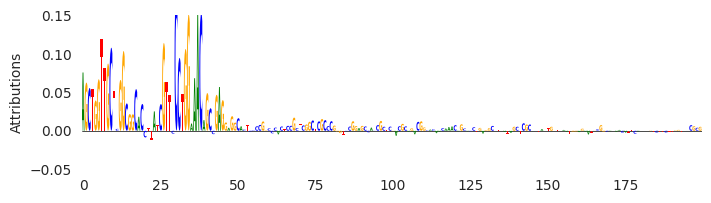

In [33]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [34]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(915, 'C', 'G'),
 (949, 'C', 'A'),
 (951, 'A', 'T'),
 (956, 'G', 'C'),
 (964, 'G', 'T'),
 (975, 'T', 'A'),
 (983, 'T', 'G'),
 (994, 'T', 'A'),
 (1002, 'A', 'G'),
 (1008, 'G', 'A')]

In [35]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 759.786890978622
mutated counts: 29475.95095022961


((1000,), (1000,))

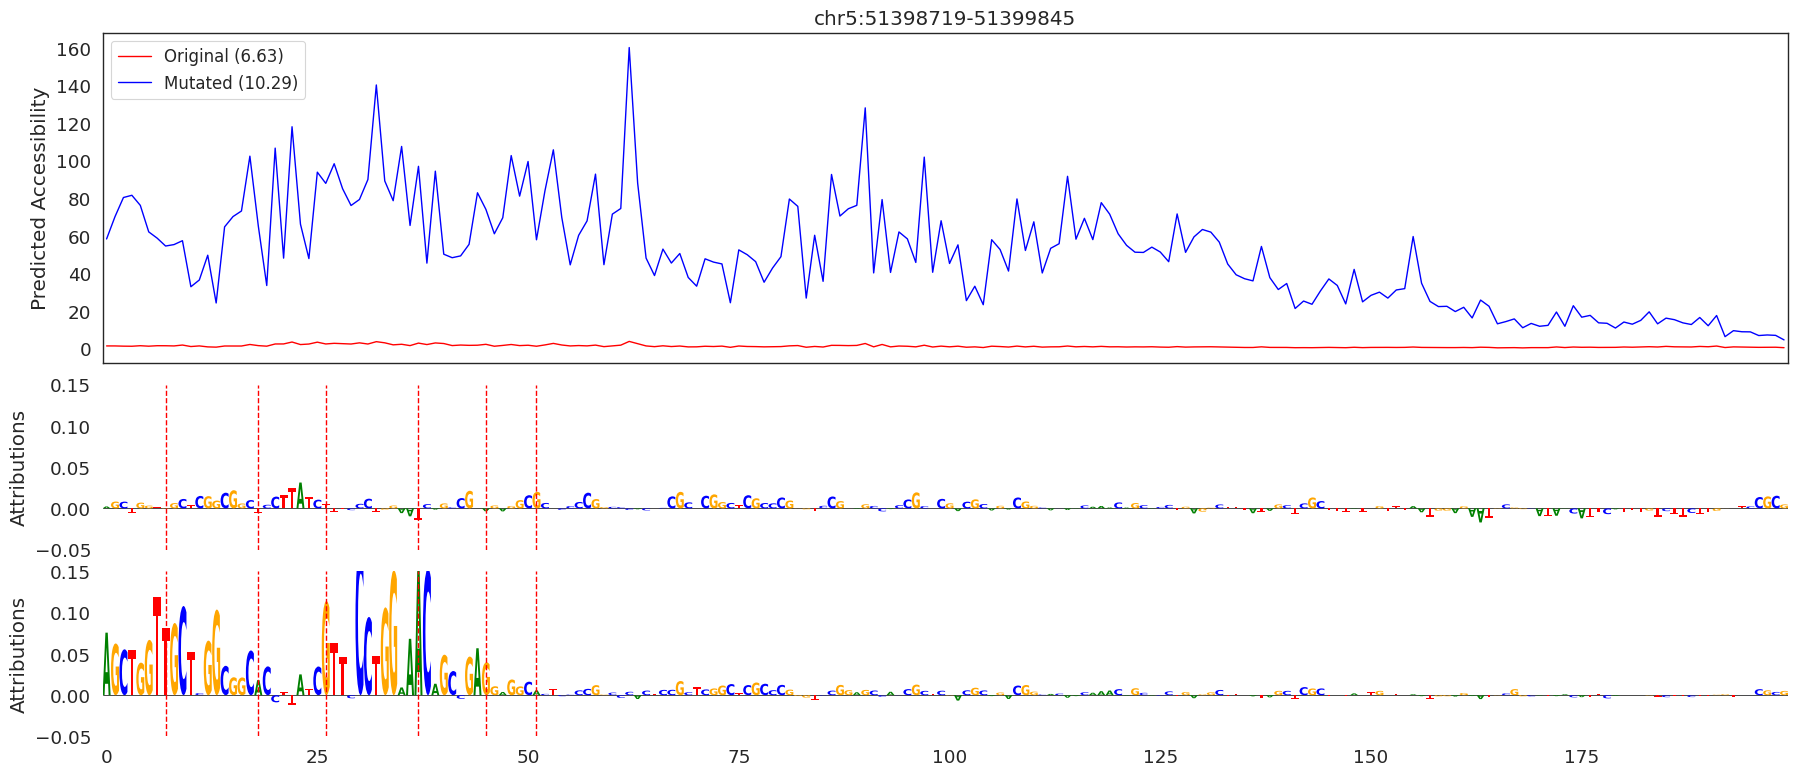

In [36]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [37]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [38]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,RFX6_MOUSE.H11MO.0.C,982,1001,1.351235,0.002500
1,ELK1_HUMAN.H11MO.0.B,851,866,-0.023214,0.016667
2,FOXD2_forkhead_1,943,958,0.807571,0.025707


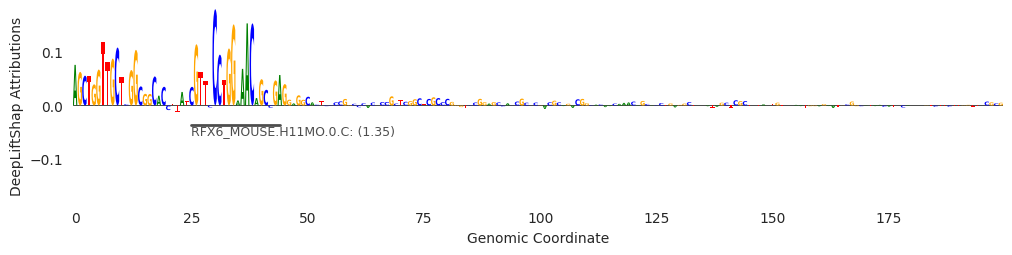

In [39]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

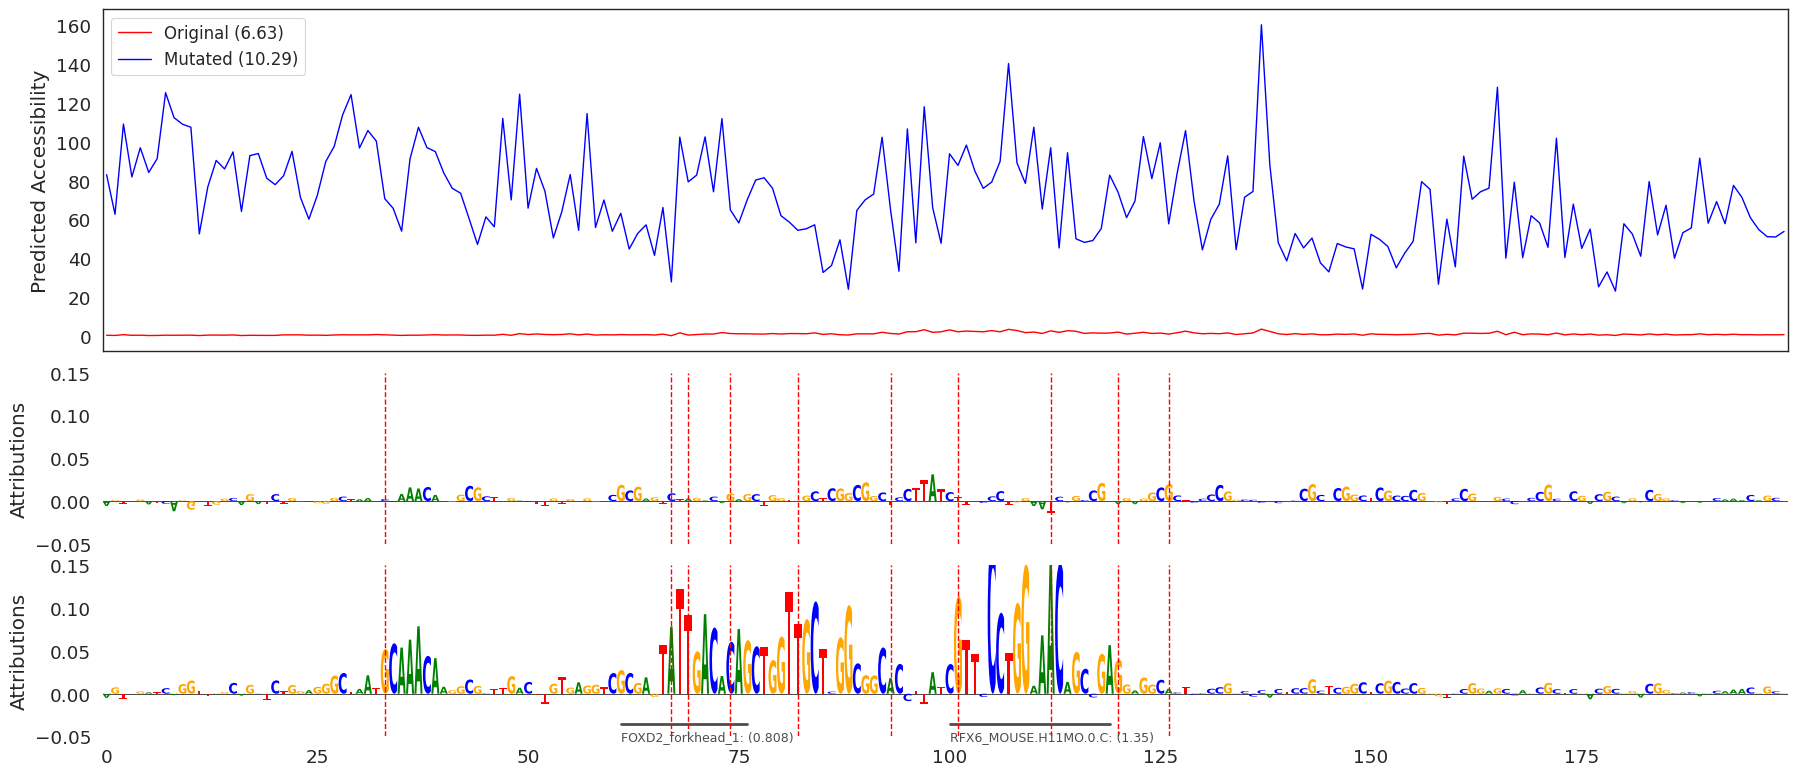

In [41]:
offset = -75

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [42]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 72.56it/s]


## Enhancer #2

In [43]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[1]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[1]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51392398-51392614: 5.798398494720459


In [44]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51392298-51392714


In [45]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [46]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [47]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00, 321.33it/s]


tensor([[5.7981]])

In [48]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 5.798
Iteration 1/10

 - y_hat: 6.262
Iteration 2/10 - y_hat: 6.765
Iteration 3/10 - y_hat: 7.327
Iteration 4/10 - y_hat: 7.738
Iteration 5/10 - y_hat: 8.123
Iteration 6/10 - y_hat: 8.456
Iteration 7/10 - y_hat: 8.863
Iteration 8/10 - y_hat: 9.236
Iteration 9/10 - y_hat: 9.497
Iteration 10/10 - y_hat: 9.864


In [49]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.58it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

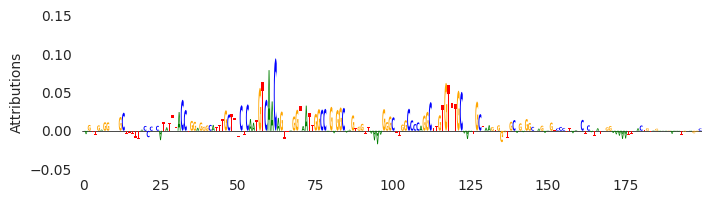

In [50]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

(-0.05, 0.15)

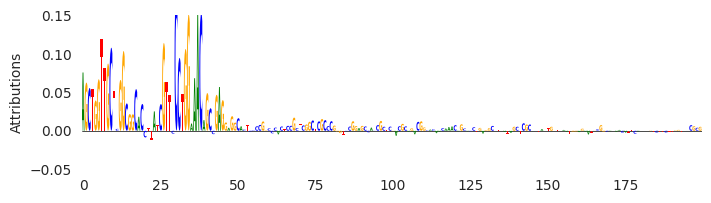

In [51]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [52]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(943, 'T', 'C'),
 (972, 'T', 'G'),
 (997, 'G', 'T'),
 (1031, 'T', 'C'),
 (1043, 'A', 'G'),
 (1092, 'G', 'T'),
 (1119, 'T', 'A'),
 (1121, 'A', 'C'),
 (1127, 'G', 'T'),
 (1131, 'A', 'T')]

In [53]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 329.7111177982448
mutated counts: 19223.283469533824


((1000,), (1000,))

In [54]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [55]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,ETV6_MOUSE.H11MO.0.C,982,1001,1.351235,0.002500
1,ETV6_MOUSE.H11MO.0.C,851,866,-0.023214,0.016667
2,ETV6_MOUSE.H11MO.0.C,943,958,0.807571,0.025707


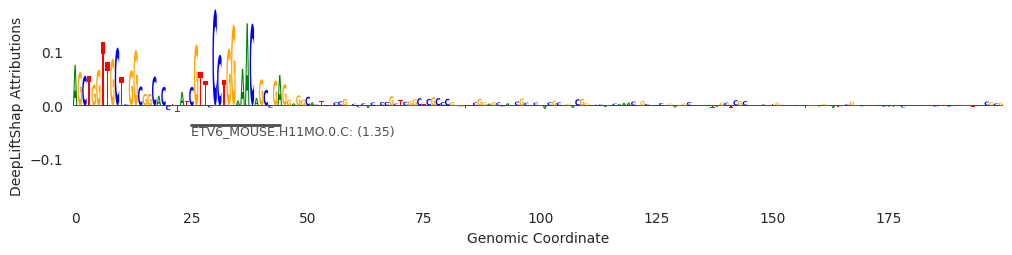

In [56]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

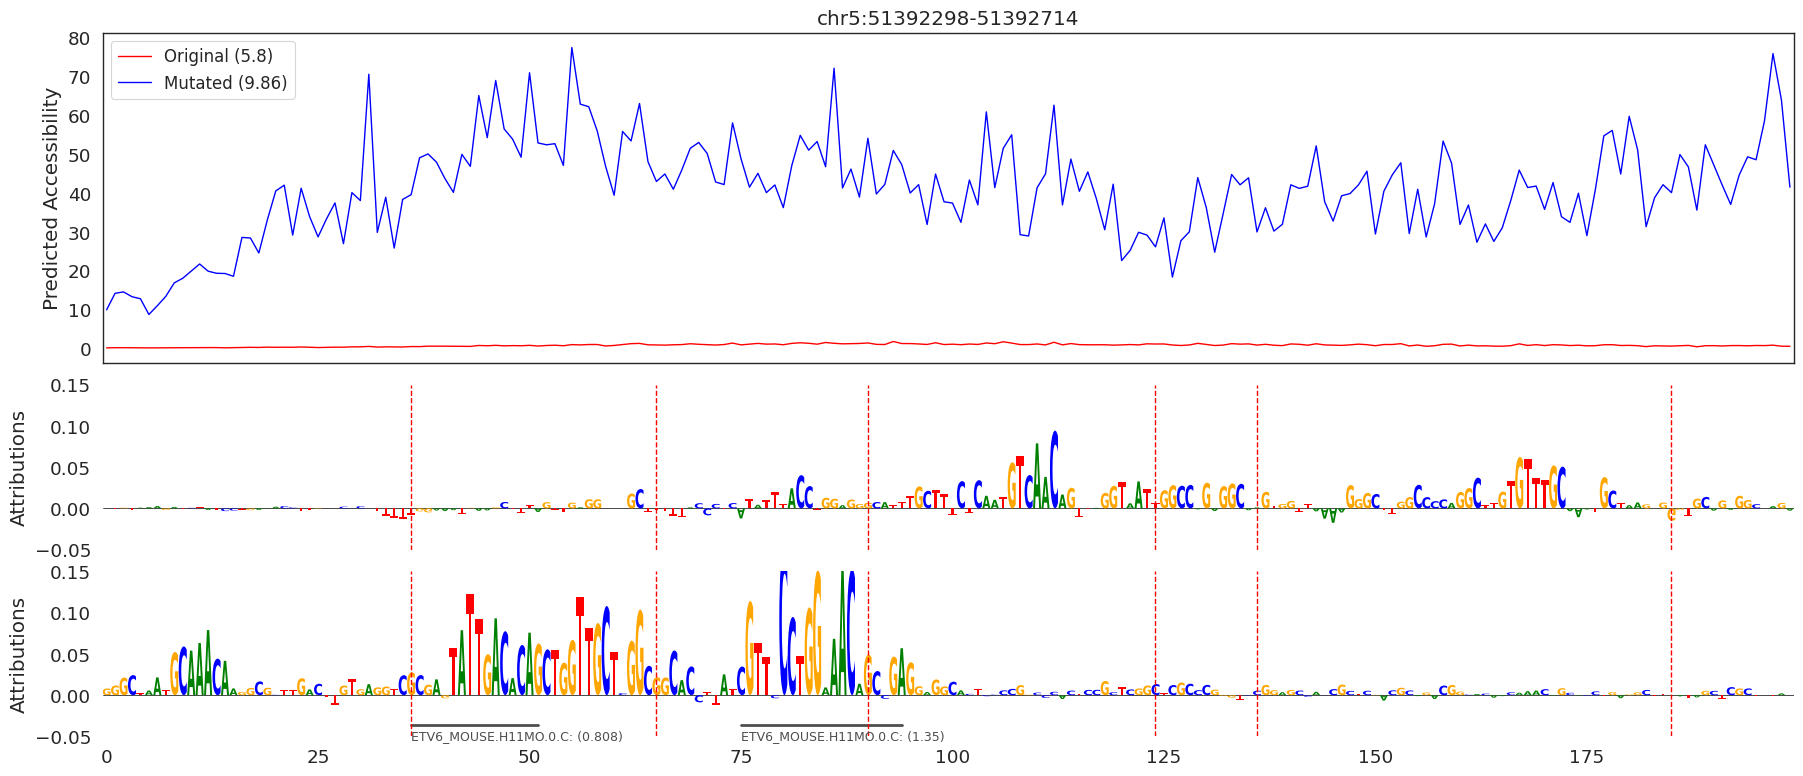

In [57]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [58]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 106.95it/s]


In [59]:
len(X_optimized)

2

## Enhancer #3

In [60]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[2]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[2]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51226455-51226670: 4.258169174194336


In [61]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51226355-51226770


In [62]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [63]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [64]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00, 454.72it/s]


tensor([[4.2579]])

In [65]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 4.258
Iteration 1/10

 - y_hat: 4.819
Iteration 2/10 - y_hat: 6.086
Iteration 3/10 - y_hat: 6.837
Iteration 4/10 - y_hat: 7.277
Iteration 5/10 - y_hat: 7.606
Iteration 6/10 - y_hat: 7.952
Iteration 7/10 - y_hat: 8.182
Iteration 8/10 - y_hat: 8.491
Iteration 9/10 - y_hat: 8.733
Iteration 10/10 - y_hat: 8.964


In [66]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.55it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

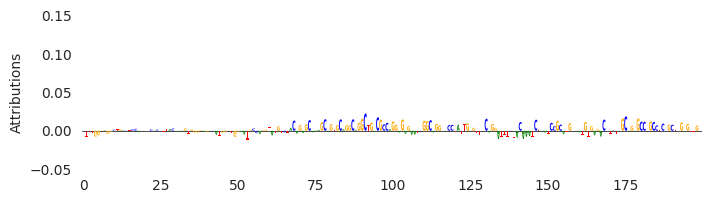

In [67]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [68]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.61it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

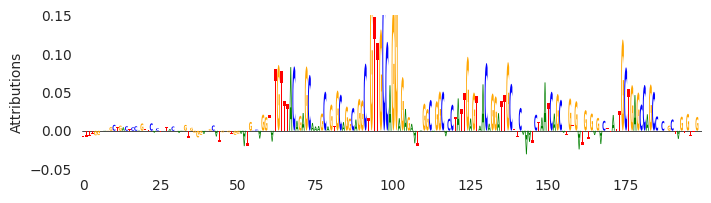

In [69]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [70]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(1022, 'C', 'T'),
 (1051, 'A', 'T'),
 (1052, 'C', 'T'),
 (1073, 'T', 'C'),
 (1085, 'T', 'A'),
 (1094, 'T', 'G'),
 (1097, 'A', 'T'),
 (1109, 'C', 'A'),
 (1116, 'A', 'G'),
 (1133, 'A', 'T')]

In [71]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 70.64264857281363
mutated counts: 7804.232034705363


((1000,), (1000,))

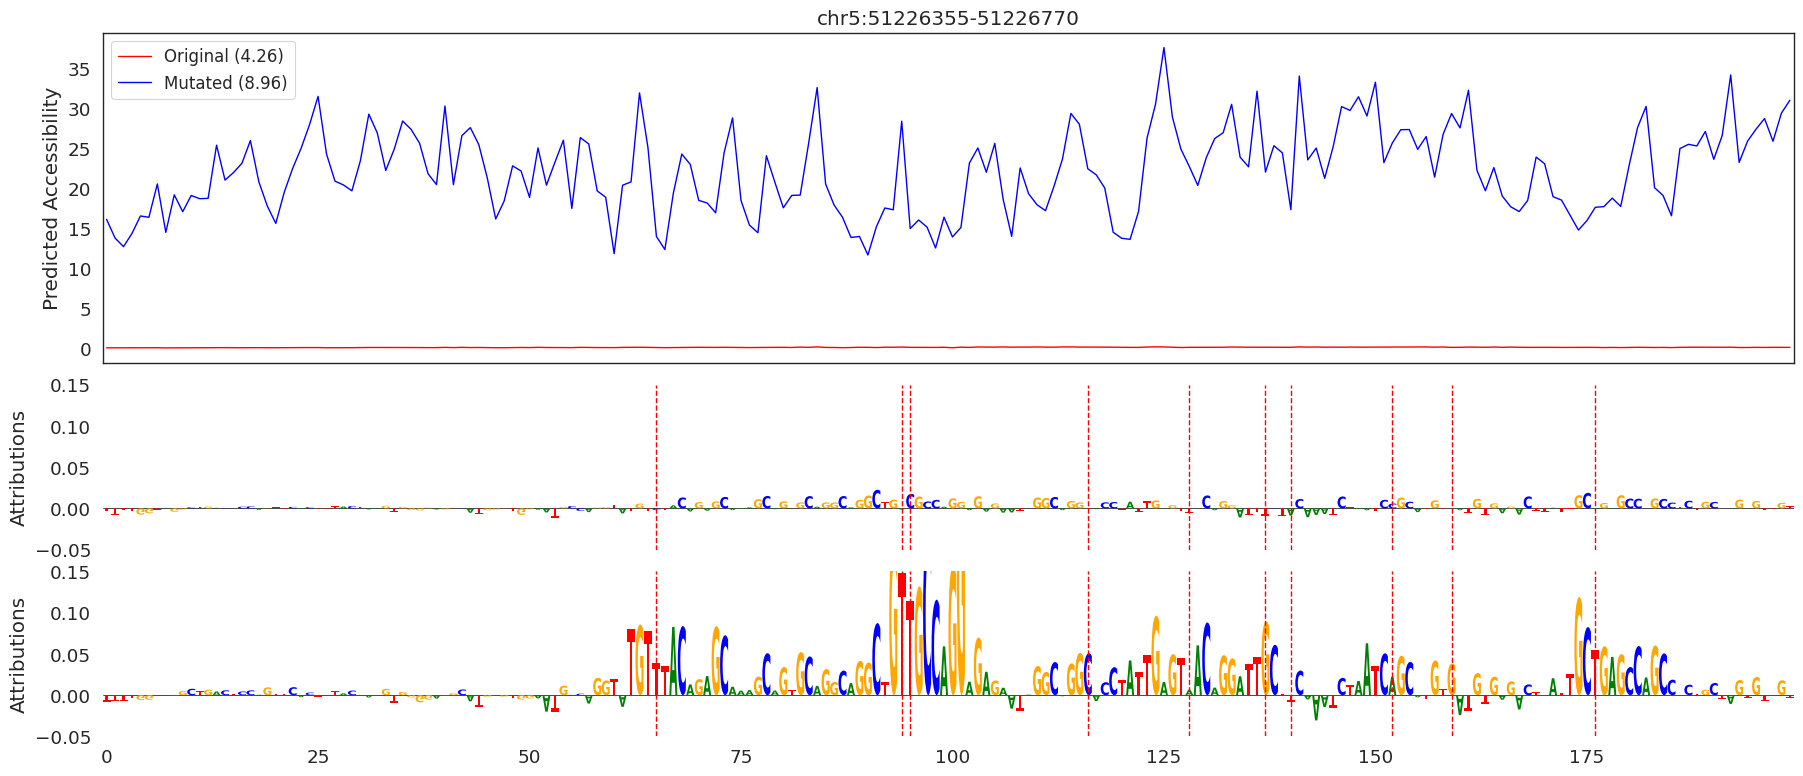

In [72]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [73]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [74]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,RFX6_MOUSE.H11MO.0.C,1045,1066,1.697056,0.006472
1,HNF4G_MA0484.1,1001,1016,-0.050682,0.017045


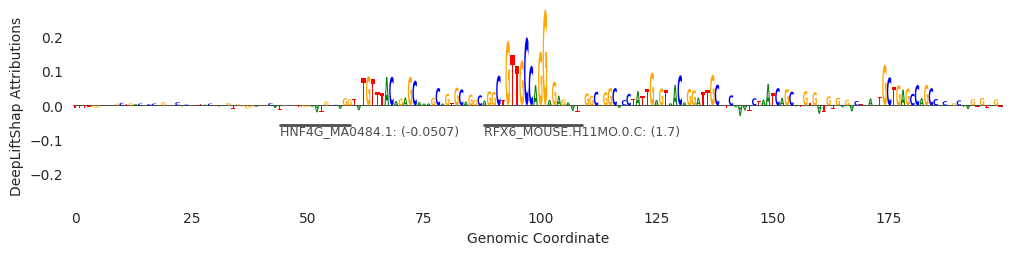

In [75]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

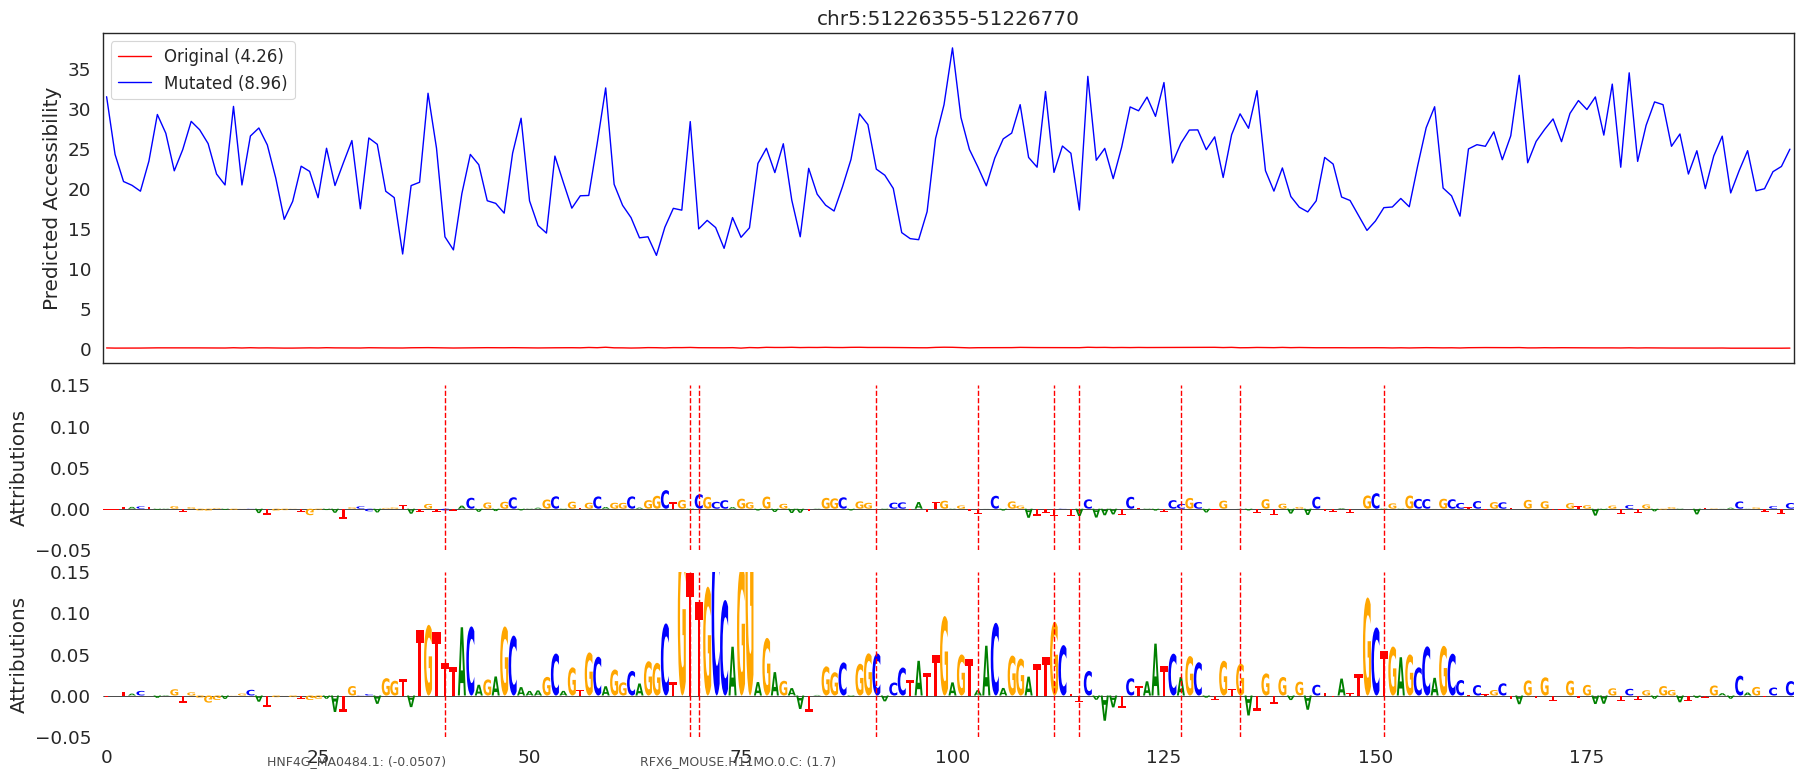

In [76]:
offset = 25

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [77]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 72.02it/s]


# 2nd Histogram

In [78]:
optimized_df = pd.DataFrame(X_optimized, columns=["chrom", "start", "end", "optimized_counts"])
optimized_df["optimized_counts"] = optimized_df["optimized_counts"].apply(lambda x: x[0])
optimized_df

,chrom,start,end,optimized_counts
0,chr5,51398819,51399745,10.291330
1,chr5,51392398,51392614,9.863878
2,chr5,51226455,51226670,8.962421


In [79]:
# Add optimized counts for 
peaks_selected = peaks_selected.merge(optimized_df, how='left', on=["chrom", "start", "end"])
peaks_selected

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,enhancer_annotation,optimized_counts
0,chr5,41903843,41904685,.,1000,.,25.707035,4235.699707,4229.604004,364,8.987947,9.657027,NaN,NaN
1,chr5,783990,785587,.,1000,.,21.533508,3944.406738,3938.589600,812,8.837391,8.328278,NaN,NaN
2,chr5,56909142,56910475,.,1000,.,22.773279,3827.583252,3821.925049,797,8.929965,8.686061,NaN,NaN
3,chr5,139198099,139198659,.,1000,.,29.588324,3808.457275,3802.825195,317,8.570924,9.214508,NaN,NaN
4,chr5,151252466,151253343,.,1000,.,21.599245,3804.431641,3798.804688,412,9.066355,9.375504,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13221,chr5,146376966,146377292,.,14,.,1.834072,2.863520,1.450777,115,4.442651,5.649552,NaN,NaN
13222,chr5,149142411,149142615,.,14,.,1.415962,2.856770,1.450777,94,6.025866,5.273196,NaN,NaN
13223,chr5,131511603,131511804,.,14,.,1.834072,2.863520,1.450777,60,4.234107,4.296594,NaN,NaN
13224,chr5,33980962,33981290,.,13,.,1.788171,2.774640,1.376034,210,4.465908,4.362654,NaN,NaN


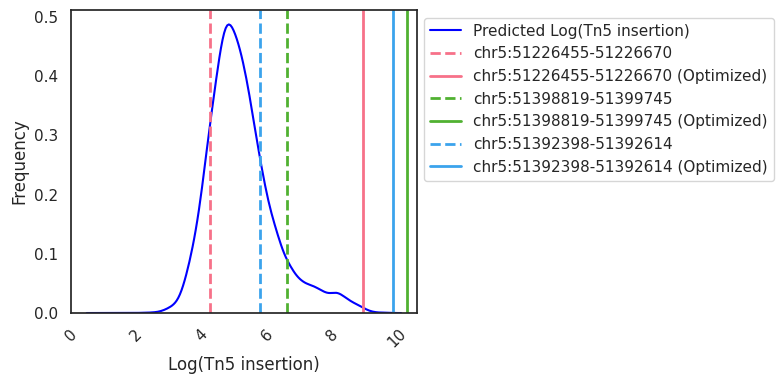

In [80]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.kdeplot(
        peaks_selected["log_counts_pred"],
        color='blue',
        label='Predicted Log(Tn5 insertion)',
        ax=ax
    )

    # Plot each ISL1 enhancer as a vertical line each with a different color
    enhancer_colors = sns.color_palette("husl", peaks_selected["enhancer_annotation"].nunique())
    for i, (enhancer_name, group) in enumerate(peaks_selected.groupby("enhancer_annotation")):
        if enhancer_name.startswith("Enhancer_"):
            enhancer_color = enhancer_colors[i % len(enhancer_colors)]
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"

            # unoptimized enhancer
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=enhancer_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

            # optimized enhancer
            if not group["optimized_counts"].isnull().all():
                ax.axvline(
                    x=group["optimized_counts"].mean(),
                    color=enhancer_color,
                    linestyle='-',
                    linewidth=2,
                    label=f"{locus} (Optimized)"
                )

        # Also plot the predicted counts for the optimized enhancer
    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, "ISL1_enhancer_predictions_histogram.pdf"), bbox_inches='tight', dpi=300)

In [81]:
peaks_selected.to_csv("ISL1_enhancer_predictions.csv", index=False)

# DONE!

---